<a href="https://colab.research.google.com/github/rayssasnt/modelo-atraso-voo/blob/main/modelo_atraso_voo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
url = 'https://raw.githubusercontent.com/rayssasnt/modelo-atraso-voo/refs/heads/main/flights.csv'
df = pd.read_csv(url)
df.head()
# id
#  companhias aéreas
# tipo aeronave
# origem
# hora de chegada
# hora saida
# atraso em mim

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271


In [2]:
df.describe().round()

,flight_id,arrival_time,departure_time,day,year,delay
count,71175.0,71175.0,71175.0,71175.0,71175.0,71175.0
mean,15.0,13.0,16.0,182.0,2016.0,13.0
std,9.0,4.0,4.0,105.0,4.0,23.0
min,1.0,7.0,10.0,0.0,2010.0,-41.0
25%,8.0,9.0,13.0,91.0,2013.0,-4.0
50%,15.0,14.0,16.0,182.0,2016.0,10.0
75%,23.0,17.0,20.0,273.0,2019.0,28.0
max,30.0,19.0,23.0,364.0,2022.0,126.0


In [3]:
df.describe(include='O')

,airline,aircraft_type,schengen,origin
count,71175,71175,71175,71175
unique,3,6,2,10
top,BZ,Airbus A320,schengen,TZF
freq,47598,30778,42569,14162


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flight_id       71175 non-null  int64  
 1   airline         71175 non-null  object 
 2   aircraft_type   71175 non-null  object 
 3   schengen        71175 non-null  object 
 4   origin          71175 non-null  object 
 5   arrival_time    71175 non-null  float64
 6   departure_time  71175 non-null  float64
 7   day             71175 non-null  int64  
 8   year            71175 non-null  int64  
 9   is_holiday      71175 non-null  bool   
 10  delay           71175 non-null  float64
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 5.5+ MB


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
average_delay = df.groupby('airline')['delay'].mean().reset_index()
average_delay

,airline,delay
0,BZ,3.077595
1,MM,40.498007
2,YE,25.772248


/tmp/ipython-input-1151/1512421646.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='airline', y='delay',


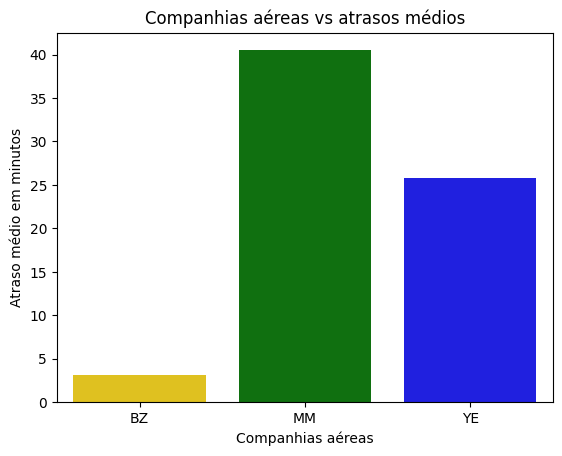

/tmp/ipython-input-1151/1512421646.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='airline',palette='flare')


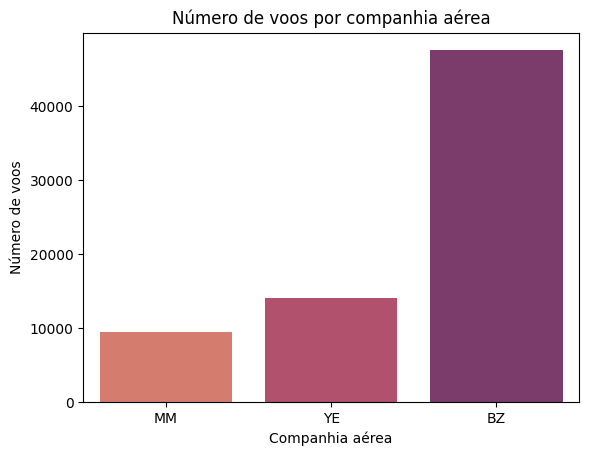

In [7]:
cor = ['gold','green','blue']

average_delay = df.groupby('airline')['delay'].mean().reset_index()

sns.barplot(x='airline', y='delay',
            data=average_delay,
            palette=cor)


plt.title('Companhias aéreas vs atrasos médios')
plt.xlabel('Companhias aéreas')
plt.ylabel('Atraso médio em minutos')
plt.show()

sns.countplot(data=df, x='airline',palette='flare')
plt.title('Número de voos por companhia aérea')
plt.xlabel('Companhia aérea')
plt.ylabel('Número de voos')
plt.show()

/tmp/ipython-input-1151/854195517.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='schengen', y='delay', data=average_delay,palette='flare')


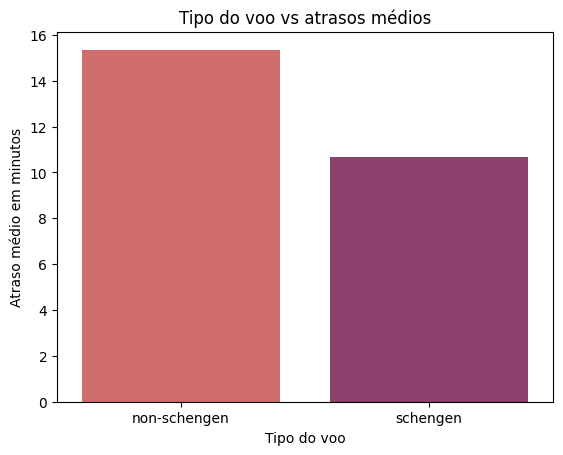

/tmp/ipython-input-1151/854195517.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='schengen',palette='pastel6')


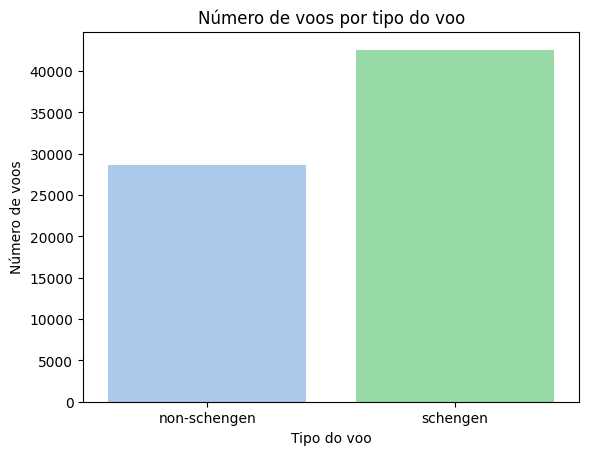

In [8]:
average_delay = df.groupby('schengen')['delay'].mean().reset_index()
sns.barplot(x='schengen', y='delay', data=average_delay,palette='flare')
plt.title('Tipo do voo vs atrasos médios')
plt.xlabel('Tipo do voo')
plt.ylabel('Atraso médio em minutos')
plt.show()

sns.countplot(data=df, x='schengen',palette='pastel6')
plt.title('Número de voos por tipo do voo')
plt.xlabel('Tipo do voo')
plt.ylabel('Número de voos')
plt.show()

/tmp/ipython-input-1151/73570837.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='aircraft_type', order = order,


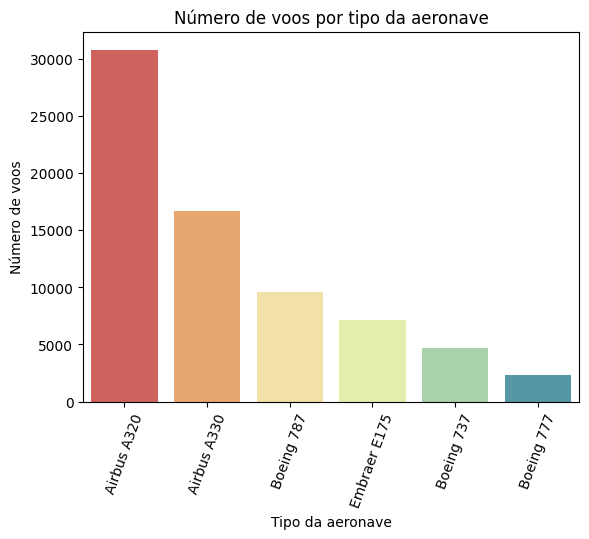

In [9]:
order = df['aircraft_type'].value_counts().index
sns.countplot(data=df, x='aircraft_type', order = order,
              palette='Spectral')
plt.title('Número de voos por tipo da aeronave')
plt.xticks(rotation=70)
plt.xlabel('Tipo da aeronave')
plt.ylabel('Número de voos')
plt.show()

/tmp/ipython-input-1151/1529354012.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='is_holiday', y='delay', data=average_delay,palette=['red','green'])


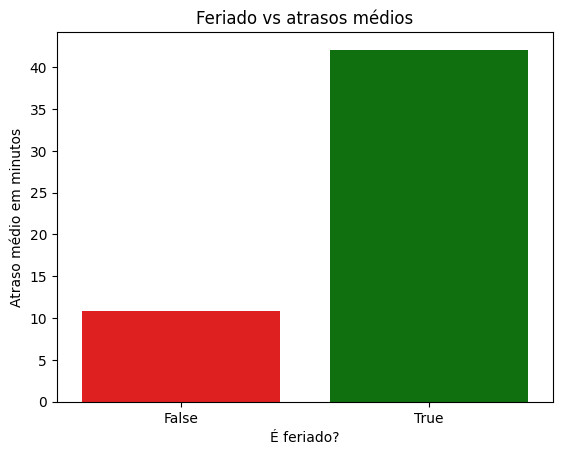

In [10]:
average_delay = df.groupby('is_holiday')['delay'].mean().reset_index()
sns.barplot(x='is_holiday', y='delay', data=average_delay,palette=['red','green'])
plt.title('Feriado vs atrasos médios')
plt.xlabel('É feriado?')
plt.ylabel('Atraso médio em minutos')
plt.show()

<Axes: xlabel='arrival_time', ylabel='Count'>

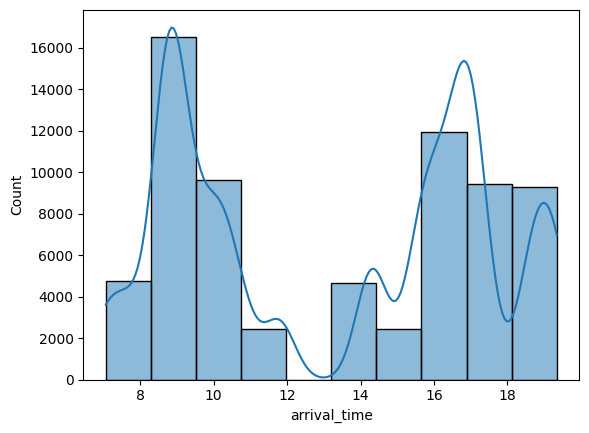

In [11]:
sns.histplot(data=df, x='arrival_time', kde=True, bins=10)

In [12]:
df.head(1)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981


In [13]:
df['year'].astype(str) + '-' + (df['day'] + 1).astype(str)

,0
0,2010-1
1,2010-1
2,2010-1
3,2010-1
4,2010-1
...,...
71170,2022-365
71171,2022-365
71172,2022-365
71173,2022-365


In [14]:
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + (df['day'] + 1).astype(str),format='%Y-%j')

In [15]:
df

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981,2010-01-01
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609,2010-01-01
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305,2010-01-01
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491,2010-01-01
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271,2010-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...
71170,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,364,2022,True,25.677277,2022-12-31
71171,17,BZ,Airbus A330,non-schengen,CNU,16.718722,21.718722,364,2022,True,52.624348,2022-12-31
71172,7,MM,Boeing 787,schengen,TZF,8.564949,13.564949,364,2022,True,56.167080,2022-12-31
71173,5,BZ,Airbus A320,schengen,ZQO,9.344097,12.344097,364,2022,True,56.758844,2022-12-31


In [16]:
# final de semana ou nao
df['is_weekend']= df['date'].dt.weekday.isin([5,6])
df

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981,2010-01-01,False
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609,2010-01-01,False
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305,2010-01-01,False
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491,2010-01-01,False
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271,2010-01-01,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71170,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,364,2022,True,25.677277,2022-12-31,True
71171,17,BZ,Airbus A330,non-schengen,CNU,16.718722,21.718722,364,2022,True,52.624348,2022-12-31,True
71172,7,MM,Boeing 787,schengen,TZF,8.564949,13.564949,364,2022,True,56.167080,2022-12-31,True
71173,5,BZ,Airbus A320,schengen,ZQO,9.344097,12.344097,364,2022,True,56.758844,2022-12-31,True


In [17]:
df['day_name'] = df['date'].dt.day_name()
df.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981,2010-01-01,False,Friday
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609,2010-01-01,False,Friday
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305,2010-01-01,False,Friday
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491,2010-01-01,False,Friday
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271,2010-01-01,False,Friday


In [18]:
categoricas = ['airline','aircraft_type' ,'schengen' ,'origin','is_holiday','is_weekend','day_name']

In [19]:
for col in categoricas:
    print(f'\nColuna: {col}')
    print(df[col].unique())


Coluna: airline
['MM' 'YE' 'BZ']

Coluna: aircraft_type
['Airbus A320' 'Embraer E175' 'Airbus A330' 'Boeing 777' 'Boeing 787'
 'Boeing 737']

Coluna: schengen
['non-schengen' 'schengen']

Coluna: origin
['TCY' 'TZF' 'EMM' 'FJB' 'AUZ' 'CSF' 'MWL' 'ZQO' 'CNU' 'PUA']

Coluna: is_holiday
[False  True]

Coluna: is_weekend
[False  True]

Coluna: day_name
['Friday' 'Saturday' 'Sunday' 'Monday' 'Tuesday' 'Wednesday' 'Thursday']


In [20]:
df['schengen'].replace({'non-schengen': 0, 'schengen': 1})

/tmp/ipython-input-1151/2738507489.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['schengen'].replace({'non-schengen': 0, 'schengen': 1})


,schengen
0,0
1,0
2,1
3,0
4,0
...,...
71170,1
71171,0
71172,1
71173,1


In [21]:
df['schengen'] = df['schengen'].replace({'non-schengen': 0, 'schengen': 1})
df['is_holiday'] = df['is_holiday'].replace({False: 0, True: 1})
df['is_weekend'] = df['is_weekend'].replace({False: 0, True: 1})
df.head()

/tmp/ipython-input-1151/1117968550.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['schengen'] = df['schengen'].replace({'non-schengen': 0, 'schengen': 1})
/tmp/ipython-input-1151/1117968550.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_holiday'] = df['is_holiday'].replace({False: 0, True: 1})
/tmp/ipython-input-1151/1117968550.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
0,26,MM,Airbus A320,0,TCY,8.885071,10.885071,0,2010,0,70.205981,2010-01-01,0,Friday
1,10,YE,Airbus A320,0,TCY,8.939996,11.939996,0,2010,0,38.484609,2010-01-01,0,Friday
2,3,BZ,Embraer E175,1,TZF,18.635384,22.635384,0,2010,0,2.388305,2010-01-01,0,Friday
3,28,BZ,Airbus A330,0,EMM,15.967963,17.967963,0,2010,0,19.138491,2010-01-01,0,Friday
4,15,BZ,Airbus A330,0,FJB,16.571894,19.571894,0,2010,0,15.016271,2010-01-01,0,Friday


In [22]:
variaveis_categoricas = ['airline', 'aircraft_type', 'origin', 'day_name']

# Encoding

In [23]:
df_encoded = pd.get_dummies(data=df, columns=variaveis_categoricas, dtype=int)
df_encoded.head()

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
0,26,0,8.885071,10.885071,0,2010,0,70.205981,2010-01-01,0,...,1,0,0,1,0,0,0,0,0,0
1,10,0,8.939996,11.939996,0,2010,0,38.484609,2010-01-01,0,...,1,0,0,1,0,0,0,0,0,0
2,3,1,18.635384,22.635384,0,2010,0,2.388305,2010-01-01,0,...,0,1,0,1,0,0,0,0,0,0
3,28,0,15.967963,17.967963,0,2010,0,19.138491,2010-01-01,0,...,0,0,0,1,0,0,0,0,0,0
4,15,0,16.571894,19.571894,0,2010,0,15.016271,2010-01-01,0,...,0,0,0,1,0,0,0,0,0,0


In [24]:
df = df_encoded.drop(["flight_id", "departure_time", "day", "year", "date"], axis=1)
df.head()

,schengen,arrival_time,is_holiday,delay,is_weekend,airline_BZ,airline_MM,airline_YE,aircraft_type_Airbus A320,aircraft_type_Airbus A330,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
0,0,8.885071,0,70.205981,0,0,1,0,1,0,...,1,0,0,1,0,0,0,0,0,0
1,0,8.939996,0,38.484609,0,0,0,1,1,0,...,1,0,0,1,0,0,0,0,0,0
2,1,18.635384,0,2.388305,0,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0
3,0,15.967963,0,19.138491,0,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
4,0,16.571894,0,15.016271,0,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0


# Treino e Teste

In [25]:
x = df.drop(columns='delay',axis=1)
y = df['delay']

In [26]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)

In [27]:
from sklearn.dummy import DummyRegressor

model_dummy = DummyRegressor()
model_dummy.fit(x_train, y_train)

DummyRegressor()

In [28]:
y_pred = model_dummy.predict(x_test)

In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


def calcular_metricas(y_test, y_pred):
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  metricas = {
      'Raiz do Erro Quadrático Médio': round(rmse, 4),
      'Erro Absoluto Médio': round(mae, 4),
      'R2 Score': round(r2, 4)
  }

  return metricas

In [30]:
calcular_metricas(y_test, y_pred)

{'Raiz do Erro Quadrático Médio': np.float64(23.2241),
 'Erro Absoluto Médio': 18.6127,
 'R2 Score': -0.0}

In [31]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor()
model_rf.fit(x_train, y_train)
y_pred_rf = model_rf.predict(x_test)
calcular_metricas(y_test, y_pred_rf)

{'Raiz do Erro Quadrático Médio': np.float64(13.2424),
 'Erro Absoluto Médio': 10.6067,
 'R2 Score': 0.6749}

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


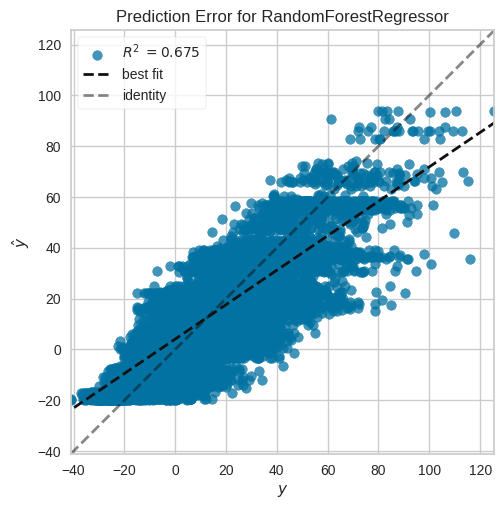

In [32]:
from yellowbrick.regressor import prediction_error

visualizer = prediction_error(model_rf, x_train, y_train, x_test, y_test)

# Validação Cruzada

In [33]:
from sklearn.model_selection import KFold, cross_validate

scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(model_rf, x_train, y_train, cv=cv, scoring=scoring)
cv_results

{'fit_time': array([5.50453782, 3.29659677, 4.23306251, 3.31032515, 3.30806732]),
 'score_time': array([0.09760714, 0.10505414, 0.09983635, 0.09490609, 0.09517431]),
 'test_mae': array([-10.64787905, -10.90831054, -10.66550314, -10.74517466,
        -10.78938355]),
 'test_rmse': array([-13.22319588, -13.57288856, -13.31006867, -13.39632   ,
        -13.4336283 ]),
 'test_r2': array([0.67413427, 0.64935715, 0.66977282, 0.66534112, 0.66035688])}

In [34]:
for metric in scoring.keys():
    scores = cv_results[f'test_{metric}']
    mean_score = "{:.3f}".format(scores.mean())
    std_score = "{:.3f}".format(scores.std())

    print(f"{metric.upper()} Scores: {[f' {val:.3f}' for val in scores]}")
    print(f"{metric.upper()} Média: {mean_score}, Std: {std_score}")
    print('----------------------------------------------------------------------------------')

MAE Scores: [' -10.648', ' -10.908', ' -10.666', ' -10.745', ' -10.789']
MAE Média: -10.751, Std: 0.094
----------------------------------------------------------------------------------
RMSE Scores: [' -13.223', ' -13.573', ' -13.310', ' -13.396', ' -13.434']
RMSE Média: -13.387, Std: 0.118
----------------------------------------------------------------------------------
R2 Scores: [' 0.674', ' 0.649', ' 0.670', ' 0.665', ' 0.660']
R2 Média: 0.664, Std: 0.009
----------------------------------------------------------------------------------


# Features Importantes

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


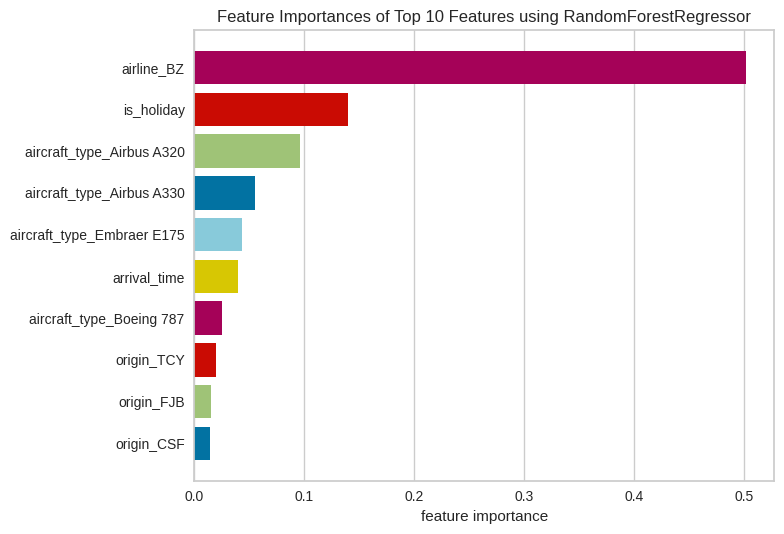

<Axes: title={'center': 'Feature Importances of Top 10 Features using RandomForestRegressor'}, xlabel='feature importance'>

In [35]:
from yellowbrick.model_selection import FeatureImportances

viz = FeatureImportances(model_rf, relative=False, topn=10)
viz.fit(x_train, y_train)
viz.show()

In [36]:
importances = model_rf.feature_importances_

feature_importances = pd.DataFrame({'Features': x.columns, 'Importances': importances}).sort_values('Importances', ascending=False)

feature_importances

,Features,Importances
4,airline_BZ,0.502328
2,is_holiday,0.139845
7,aircraft_type_Airbus A320,0.096274
8,aircraft_type_Airbus A330,0.055291
12,aircraft_type_Embraer E175,0.043447
1,arrival_time,0.040058
11,aircraft_type_Boeing 787,0.025025
20,origin_TCY,0.019700
17,origin_FJB,0.015429
15,origin_CSF,0.014627


In [37]:
results_df = pd.DataFrame(index=['RMSE', 'MAE', 'R2'])

model_selected_features = RandomForestRegressor(random_state=42, max_depth=5)

for count in [1, 5, 10, 15, 20, 25, 30]:
  selected_features = feature_importances['Features'].values[:count]

  X_train_selected = x_train[selected_features]
  X_test_selected = x_test[selected_features]

  model_selected_features.fit(X_train_selected, y_train)

  y_pred = model_selected_features.predict(X_test_selected)

  metricas = calcular_metricas(y_test, y_pred)

  results_df[count] = list(metricas.values())

results_df

,1,5,10,15,20,25,30
RMSE,18.8639,15.1651,13.7423,13.7376,13.7312,13.7310,13.7301
MAE,14.9854,12.0714,11.0279,11.0255,11.0148,11.0142,11.0138
R2,0.3402,0.5736,0.6499,0.6501,0.6504,0.6504,0.6505


In [38]:
importances = model_rf.feature_importances_
feature_importances = pd.DataFrame({'Features': x.columns, 'Importances': importances})
feature_importances.sort_values('Importances', ascending=False)

,Features,Importances
4,airline_BZ,0.502328
2,is_holiday,0.139845
7,aircraft_type_Airbus A320,0.096274
8,aircraft_type_Airbus A330,0.055291
12,aircraft_type_Embraer E175,0.043447
1,arrival_time,0.040058
11,aircraft_type_Boeing 787,0.025025
20,origin_TCY,0.019700
17,origin_FJB,0.015429
15,origin_CSF,0.014627


In [39]:
results_df = pd.DataFrame(index=['RMSE', 'MAE', 'R2'])

model_selected_features = RandomForestRegressor(random_state=42, max_depth=5)

for count in range(10, 16):
  selected_features = feature_importances['Features'].values[:count]

  X_train_selected = x_train[selected_features]
  X_test_selected = x_test[selected_features]

  model_selected_features.fit(X_train_selected, y_train)

  y_pred = model_selected_features.predict(X_test_selected)

  metricas = calcular_metricas(y_test, y_pred)

  results_df[count] = list(metricas.values())

results_df

,10,11,12,13,14,15
RMSE,14.3002,14.3002,14.3939,13.7410,13.7410,13.7406
MAE,11.4904,11.4904,11.4096,11.0256,11.0254,11.0253
R2,0.6208,0.6208,0.6159,0.6499,0.6499,0.6499


In [40]:
selected_features = feature_importances['Features'].values[:13]
X_select_features = x[selected_features]

# Treinando o modelo novamente

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X_select_features, y, random_state=42)

## Otimizando os hiperparâmetros com GridSearch

In [42]:
param_grid = {
'max_depth': [5, 10, 15],
'min_samples_leaf': [1, 2, 3],
'min_samples_split': [2, 4, 6],
'n_estimators': [100, 150, 200]
}

In [43]:
from sklearn.model_selection import GridSearchCV

em GPU demorou 5mim para rodar ⬇ ⬇ ⬇

In [44]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

model_grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid= param_grid,
             scoring='r2', cv=cv)

model_grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [100, 150, 200]},
             scoring='r2')

In [45]:
metricas = calcular_metricas(y_test, y_pred)

In [47]:
y_pred_model_grid = model_grid.predict(X_test)

metricas_model_grid = calcular_metricas(y_test, y_pred_model_grid)
metricas_model_grid

{'Raiz do Erro Quadrático Médio': np.float64(13.2635),
 'Erro Absoluto Médio': 10.6731,
 'R2 Score': 0.6738}

In [48]:
results_df['model_grid'] = list(metricas_model_grid.values())
results_df

,10,11,12,13,14,15,model_grid
RMSE,14.3002,14.3002,14.3939,13.7410,13.7410,13.7406,13.2635
MAE,11.4904,11.4904,11.4096,11.0256,11.0254,11.0253,10.6731
R2,0.6208,0.6208,0.6159,0.6499,0.6499,0.6499,0.6738


- melhora do r² , rmse e mae